In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sweetviz as sv
import ipywidgets as widgets
from IPython.display import display, IFrame, clear_output, HTML
from pathlib import Path
import time
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (LSTM, Dense, Dropout,
                                     Conv1D, MaxPooling1D, Flatten, Input)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print(f"Imports OK -- TensorFlow {tf.__version__}")
print(f"GPU dispo : {len(tf.config.list_physical_devices('GPU')) > 0}")

Imports OK -- TensorFlow 2.21.0
GPU dispo : False


In [35]:

# CHARGEMENT DES 8 DATASETS + 4 FICHIERS RUL

from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

base_dir = Path(".")  

COLS = ['unit_id', 'cycle',
        'op_setting_1', 'op_setting_2', 'op_setting_3'] + \
       [f'sensor_{i}' for i in range(1, 22)]

# Plafond applique UNIQUEMENT sur la cible d'entrainement
# Le jeu de test est evalue contre la vraie RUL non plafonnee cette fois 
RUL_MAX = 125

def add_rul(df):
    """
    Calcule la RUL pour le jeu d'entrainement.
    Le clip(upper=RUL_MAX) s'applique seulement ici — pas sur le test.
    """
    max_cycle = df.groupby('unit_id')['cycle'].max().rename('max_cycle')
    df = df.merge(max_cycle, on='unit_id')
    df['RUL'] = (df['max_cycle'] - df['cycle']).clip(upper=RUL_MAX)
    return df.drop(columns='max_cycle')


def split_by_motor(df_train, feature_cols, seq_len, val_ratio=0.2, random_state=42):
    """
    Point 3 — split train/val en separant les moteurs entiers.
    Evite que des fenetres chevauchantes se retrouvent a la fois
    en train et en validation, ce qui rendrait la val_loss trop optimiste.
    """
    all_units   = df_train['unit_id'].unique()
    train_units, val_units = train_test_split(
        all_units,
        test_size=val_ratio,
        random_state=random_state
    )

    df_t = df_train[df_train['unit_id'].isin(train_units)]
    df_v = df_train[df_train['unit_id'].isin(val_units)]

    X_t, y_t = build_sequences(df_t, seq_len, feature_cols)
    X_v, y_v = build_sequences(df_v, seq_len, feature_cols)

    print(f"  Moteurs train : {len(train_units):>4} | sequences : {X_t.shape[0]:>6}")
    print(f"  Moteurs val   : {len(val_units):>4} | sequences : {X_v.shape[0]:>6}")

    return X_t, y_t, X_v, y_v


# Chargement des datasets 
raw = {}
for split in ['train', 'test']:
    for fd in ['FD001', 'FD002', 'FD003', 'FD004']:
        name = f"{split}_{fd}"
        path = base_dir / f"{name}.xlsx"
        if path.exists():
            df = pd.read_excel(path)
            df.columns = COLS[:df.shape[1]]
            df['source'] = fd
            if split == 'train':
                df = add_rul(df)  # plafond RUL_MAX applique ici seulement
            raw[name] = df
            print(f"OK {name:<18} {df.shape[0]:>6} lignes x {df.shape[1]} colonnes")
        else:
            print(f"MANQUANT {name}.xlsx")

#  Chargement des RUL de test — NON plafonnees
rul_raw = {}
for fd in ['FD001', 'FD002', 'FD003', 'FD004']:
    path = base_dir / f"RUL_{fd}.txt"
    if path.exists():
        vals = pd.read_csv(path, header=None).values.flatten().astype(float)

        # np.minimum(vals, RUL_MAX) suprime, car ici on garde la vraie RUL
        rul_raw[fd] = vals
        print(f"OK RUL_{fd}.txt -> {len(vals)} valeurs "
              f"| min={vals.min():.0f}  max={vals.max():.0f}  "
              f"mean={vals.mean():.1f}")
    else:
        print(f"MANQUANT RUL_{fd}.txt")

print(f"\n{len(raw)} datasets + {len(rul_raw)} fichiers RUL charges.")
print(f"RUL_MAX = {RUL_MAX} cycles (plafond train uniquement)")
print("RUL test : vraie valeur non plafonnee — evaluation fidele au reel")

OK train_FD001         20631 lignes x 28 colonnes
OK train_FD002         53759 lignes x 28 colonnes
OK train_FD003         24720 lignes x 28 colonnes
OK train_FD004         61249 lignes x 28 colonnes
OK test_FD001          13096 lignes x 27 colonnes
OK test_FD002          33991 lignes x 27 colonnes
OK test_FD003          16596 lignes x 27 colonnes
OK test_FD004          41214 lignes x 27 colonnes
OK RUL_FD001.txt -> 100 valeurs | min=7  max=145  mean=75.5
OK RUL_FD002.txt -> 259 valeurs | min=6  max=194  mean=81.2
OK RUL_FD003.txt -> 100 valeurs | min=6  max=145  mean=75.3
OK RUL_FD004.txt -> 248 valeurs | min=6  max=195  mean=86.6

8 datasets + 4 fichiers RUL charges.
RUL_MAX = 125 cycles (plafond train uniquement)
RUL test : vraie valeur non plafonnee — evaluation fidele au reel


In [36]:
# Tableau recapitulatif des datasets C-MAPSS avant le merge
fault_summary = pd.DataFrame([
    {
        'Dataset': 'FD001',
        'Conditions operationnelles': 1,
        'Types de panne': 1,
        'Groupe propose': 'Ligne1 avec FD003',
    },
    {
        'Dataset': 'FD002',
        'Conditions operationnelles': 6,
        'Types de panne': 1,
        'Groupe propose': 'Ligne2 avec FD004',
    },
    {
        'Dataset': 'FD003',
        'Conditions operationnelles': 1,
        'Types de panne': 2,
        'Groupe propose': 'Ligne1 avec FD001',
    },
    {
        'Dataset': 'FD004',
        'Conditions operationnelles': 6,
        'Types de panne': 2,
        'Groupe propose': 'Ligne2 avec FD002',
    },
])

display(fault_summary)

print('Lecture du tableau :')
print('- FD001 et FD003 ont la meme condition operationnelle, mais des types de panne differents.')
print('- FD002 et FD004 ont les memes 6 conditions operationnelles, mais des types de panne differents.')

,Dataset,Conditions operationnelles,Types de panne,Groupe propose
0,FD001,1,1,Ligne1 avec FD003
1,FD002,6,1,Ligne2 avec FD004
2,FD003,1,2,Ligne1 avec FD001
3,FD004,6,2,Ligne2 avec FD002


Lecture du tableau :
- FD001 et FD003 ont la meme condition operationnelle, mais des types de panne differents.
- FD002 et FD004 ont les memes 6 conditions operationnelles, mais des types de panne differents.


La condition opérationnelle correspond au contexte de fonctionnement du moteur au moment où les mesures capteurs sont prises (régime, charge, altitude/vitesse simulée, température ambiante, etc., selon le jeu C-MAPSS).
FD001 et FD003 ont la même condition opérationnelle : les moteurs évoluent dans un seul contexte de fonctionnement.
FD002 et FD004 ont 6 conditions opérationnelles : les moteurs passent par 6 contextes de fonctionnement différents.
Mais types de panne différents.

In [37]:
# Merge des datasets
def merge_train(fd_a, fd_b):
    df_a = raw[f'train_{fd_a}'].copy()
    df_b = raw[f'train_{fd_b}'].copy()
    offset = df_a['unit_id'].max()
    df_b['unit_id'] = df_b['unit_id'] + offset
    return pd.concat([df_a, df_b], ignore_index=True)

def merge_test(fd_a, fd_b):
    df_a = raw[f'test_{fd_a}'].copy()
    df_b = raw[f'test_{fd_b}'].copy()
    offset = df_a['unit_id'].max()
    df_b['unit_id'] = df_b['unit_id'] + offset
    return pd.concat([df_a, df_b], ignore_index=True)

def merge_rul(fd_a, fd_b):
    return np.concatenate([rul_raw[fd_a], rul_raw[fd_b]])

# Ligne 1 : FD001 + FD003
train_Ligne1 = merge_train('FD001', 'FD003')
test_Ligne1  = merge_test('FD001',  'FD003')

rul_Ligne1   = merge_rul('FD001',   'FD003')

# Ligne 2 : FD002 + FD004
train_Ligne2 = merge_train('FD002', 'FD004')
test_Ligne2  = merge_test('FD002',  'FD004')
rul_Ligne2   = merge_rul('FD002',   'FD004')

print("-- Resultat du merge ------------------------------------------")
print(f"  train_Ligne1 (FD001+FD003) : {train_Ligne1.shape[0]:>7} lignes  {train_Ligne1['unit_id'].nunique()} moteurs")
print(f"  test_Ligne1  (FD001+FD003) : {test_Ligne1.shape[0]:>7} lignes  {test_Ligne1['unit_id'].nunique()} moteurs  RUL: {len(rul_Ligne1)} valeurs")
print(f"  train_Ligne2 (FD002+FD004) : {train_Ligne2.shape[0]:>7} lignes  {train_Ligne2['unit_id'].nunique()} moteurs")
print(f"  test_Ligne2  (FD002+FD004) : {test_Ligne2.shape[0]:>7} lignes  {test_Ligne2['unit_id'].nunique()} moteurs  RUL: {len(rul_Ligne2)} valeurs")

datasets_merged = {
    'train_Ligne1 (FD001+FD003)' : train_Ligne1,
    'test_Ligne1  (FD001+FD003)' : test_Ligne1,
    'train_Ligne2 (FD002+FD004)' : train_Ligne2,
    'test_Ligne2  (FD002+FD004)' : test_Ligne2,
}

-- Resultat du merge ------------------------------------------
  train_Ligne1 (FD001+FD003) :   45351 lignes  200 moteurs
  test_Ligne1  (FD001+FD003) :   29692 lignes  200 moteurs  RUL: 200 valeurs
  train_Ligne2 (FD002+FD004) :  115008 lignes  509 moteurs
  test_Ligne2  (FD002+FD004) :   75205 lignes  507 moteurs  RUL: 507 valeurs


In [38]:
# Preparation du jeu merge pour l'entrainement
# Ici on choisit la ligne à étudier, prépare X train/test proprement, et harmonise les variables pour que les modèles apprennent correctement

LINE_MAP = {
    'Ligne1': {
        'label': 'FD001+FD003',
        'train': train_Ligne1,
        'test': test_Ligne1,
        'rul_test': rul_Ligne1,
    },
    'Ligne2': {
        'label': 'FD002+FD004',
        'train': train_Ligne2,
        'test': test_Ligne2,
        'rul_test': rul_Ligne2,
    },
}

# Choix du groupe de datasets à utiliser
# Ligne1 = FD001 + FD003
# Ligne2 = FD002 + FD004
LIGNE = 'Ligne1'  # change en 'Ligne2' si besoin

cfg = LINE_MAP[LIGNE]
label = cfg['label']

df_train_m = cfg['train'].copy()
df_test_m  = cfg['test'].copy()
y_test_m   = cfg['rul_test'].copy()

# Features numeriques utilisees par les modeles
# Selection des variables d'entree (features)
# On enleve les colonnes non pertinentes pour le modele (unit_id, cycle, RUL, source)
# et on garde uniquement les colonnes numeriques dans FEATURE_COLS
EXCLUDE_COLS = {'unit_id', 'cycle', 'RUL', 'source'}
FEATURE_COLS = [
    c for c in df_train_m.columns
    if c not in EXCLUDE_COLS and pd.api.types.is_numeric_dtype(df_train_m[c])
]

# Mise a l'echelle train/test avec le meme scaler, Normalisation des donnees
# MinMaxScaler met les features entre 0 et 1 :
# fit_transform sur le train (apprend l'echelle),
# transform sur le test (reutilise la meme echelle).
# C'est important pour eviter la fuite de donnees et garder une evaluation correcte.
scaler = MinMaxScaler()
df_train_m[FEATURE_COLS] = scaler.fit_transform(df_train_m[FEATURE_COLS])
df_test_m[FEATURE_COLS]  = scaler.transform(df_test_m[FEATURE_COLS])

print(f"Configuration active: {LIGNE} ({label})")
print(f"Train: {df_train_m.shape} | Test: {df_test_m.shape}")
print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS[:5]}{' ...' if len(FEATURE_COLS) > 5 else ''}")
print(f"y_test_m: {y_test_m.shape}")

Configuration active: Ligne1 (FD001+FD003)
Train: (45351, 28) | Test: (29692, 27)
Features (24): ['op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_1', 'sensor_2'] ...
y_test_m: (200,)


In [39]:
# Construction des sequences temporelles d'entrainement et de test
# Ici l'objectif est d'eviter de lancer l'entrainement avec des donnees incoherentes.
# On veut que les modeles puissent apprendre a partir de sequences de cycles, plutot que de points isoles.

SEQ_LEN = 50   # fenetre de 50 cycles

# Validation rapide pour eviter un NameError peu explicite
required_vars = ['df_train_m', 'df_test_m', 'FEATURE_COLS', 'y_test_m']
missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise NameError(
        "Variables manquantes: "
        f"{missing_vars}. Execute d'abord la cellule de preparation du jeu merge."
    )

if not FEATURE_COLS:
    raise ValueError("FEATURE_COLS est vide. Verifie la cellule de preparation.")

missing_train_cols = [c for c in FEATURE_COLS if c not in df_train_m.columns]
missing_test_cols  = [c for c in FEATURE_COLS if c not in df_test_m.columns]
if missing_train_cols or missing_test_cols:
    raise ValueError(
        "Colonnes features manquantes. "
        f"train manquantes={missing_train_cols}, test manquantes={missing_test_cols}"
    )

if 'RUL' not in df_train_m.columns:
    raise ValueError("La colonne 'RUL' est absente de df_train_m.")


def build_sequences(df, seq_len, feature_cols):
    X_seqs, y_seqs = [], []
    for _, group in df.groupby('unit_id'):
        group    = group.sort_values('cycle')
        features = group[feature_cols].values
        labels   = group['RUL'].values
        for i in range(seq_len, len(features) + 1):
            X_seqs.append(features[i - seq_len : i])
            y_seqs.append(labels[i - 1])
    return np.array(X_seqs), np.array(y_seqs)


def build_test_sequences(df, seq_len, feature_cols):
    X_seqs = []
    for _, group in df.groupby('unit_id'):
        group    = group.sort_values('cycle')
        features = group[feature_cols].values
        if len(features) < seq_len:
            pad      = np.zeros((seq_len - len(features), len(feature_cols)))
            features = np.vstack([pad, features])
        X_seqs.append(features[-seq_len:])
    return np.array(X_seqs)


X_train_m, y_train_m = build_sequences(df_train_m, SEQ_LEN, FEATURE_COLS)
X_test_m             = build_test_sequences(df_test_m, SEQ_LEN, FEATURE_COLS)

print(f"X_train : {X_train_m.shape}  ->  (sequences, {SEQ_LEN} cycles, {len(FEATURE_COLS)} features)")
print(f"y_train : {y_train_m.shape}")
print(f"X_test  : {X_test_m.shape}   ->  (1 sequence par moteur)")
print(f"y_test  : {y_test_m.shape}   ->  RUL vraie au dernier cycle connu")

X_train : (35551, 50, 24)  ->  (sequences, 50 cycles, 24 features)
y_train : (35551,)
X_test  : (200, 50, 24)   ->  (1 sequence par moteur)
y_test  : (200,)   ->  RUL vraie au dernier cycle connu


cette cellule “Construction des séquences temporelles” sert à transformer tes tableaux bruts en format compatible avec les réseaux temporels (LSTM).

Concrètement, elle fait 3 choses :

Créer des fenêtres glissantes pour le train
Pour chaque moteur, elle prend les FEATURE_COLS triées par cycle.
Avec SEQ_LEN = 50, elle fabrique des blocs de forme (50, nb_features).
La cible associée à chaque bloc est la RUL du dernier cycle de la fenêtre.
Résultat: X_train_m et y_train_m.

Préparer le test au bon format
Pour chaque moteur du test, elle garde uniquement la dernière fenêtre de 50 cycles.
Si un moteur a moins de 50 cycles, elle complète avec du padding (zéros).
Résultat: X_test_m (une séquence par moteur).

Garantir que les entrées sont valides
Elle vérifie que les variables nécessaires existent (df_train_m, df_test_m, etc.)
Elle vérifie que les colonnes features sont cohérentes
Ça évite des erreurs floues plus tard pendant l’entraînement
Sans cette cellule, les modèles ne peuvent pas apprendre la dynamique temporelle, car ils attendent des tenseurs 3D (samples, timesteps, features) et non un DataFrame “plat”.



## Documentation rapide des modeles utilises dans le travail ci dessous:

### 1) LSTM (Deep Learning)
- **Type**: reseau de neurones recurrent (RNN)
- **Entree**: sequence 3D `(samples, timesteps, features)`
- **Objectif ici**: apprendre l'evolution temporelle de la degradation moteur sur 50 cycles
- **Points forts**: capture les dependances temporelles longues
- **Limites**: entrainement plus lent, sensible aux hyperparametres

### 2) Random Forest (Machine Learning)
- **Type**: ensemble d'arbres de decision (pas du deep learning)
- **Entree ici**: donnees aplaties 2D `(samples, timesteps * features)`
- **Objectif ici**: baseline robuste pour comparer avec les modeles DL
- **Points forts**: robuste au bruit, peu de pretraitement, interpretation possible (importance des variables)
- **Limites**: ne modelise pas naturellement la structure temporelle comme un LSTM

### Pourquoi comparer ces 2 modeles ?
- Obtenir une reference ML classique (Random Forest)
- Mesurer le gain potentiel des modeles temporels DL (LSTM)
- Choisir le meilleur compromis precision / temps de calcul pour la prediction de RUL

In [40]:
# Definition des modeles : LSTM + Random Forest
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.ensemble import RandomForestRegressor

# Validation explicite: cette cellule depend des sequences construites avant
required_vars = ['X_train_m', 'X_test_m', 'SEQ_LEN']
missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise NameError(
        "Variables manquantes: "
        f"{missing_vars}. Execute d'abord la cellule 'Construction des sequences temporelles'."
    )

n_features = X_train_m.shape[2]

def build_lstm(seq_len, n_feat):
    model = Sequential([
        LSTM(64, input_shape=(seq_len, n_feat), return_sequences=True),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(1e-3), loss='mse', metrics=['mae'])
    return model

model_lstm = build_lstm(SEQ_LEN, n_features)

# Random Forest travaille sur un tableau 2D: (echantillons, features_aplatis)
X_train_rf = X_train_m.reshape(X_train_m.shape[0], -1)
X_test_rf  = X_test_m.reshape(X_test_m.shape[0], -1)
model_rf   = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)  # à ajuster selon la puissance de calcul disponible

print(f"LSTM          : {model_lstm.count_params():,} parametres")
print(f"Random Forest : {model_rf.n_estimators} arbres | input={X_train_rf.shape[1]} features")

LSTM          : 35,745 parametres
Random Forest : 100 arbres | input=1200 features


In [41]:
# Entrainement des modeles
# Ici on lance simplement l'entraînement des 2 modèles, avec une stratégie pour éviter de sur-entraîner:
# Callbacks pour le modèle Deep Learning
# EarlyStopping: arrête l'entraînement si la validation ne s'améliore plus pendant 20 epochs, et recharge les meilleurs poids.
# ReduceLROnPlateau: baisse le learning rate de moitié si ça stagne pendant 8 epochs.
# Entraînement du modèle LSTM avec max 150 epochs (early stopping possible avant)

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import time

# Split par moteur
print(f"Split train/val par moteur — {LIGNE} ({label})")
X_t, y_t, X_v, y_v = split_by_motor(df_train_m, FEATURE_COLS, SEQ_LEN)

# X_train_rf pour Random Forest = X_t aplati (split moteur aussi)
X_t_rf = X_t.reshape(X_t.shape[0], -1)

callbacks = [
    EarlyStopping(patience=20, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=8, verbose=1)
]

#  Entrainement LSTM 
histories = {}
for name, model in [('LSTM', model_lstm)]:
    print(f"\n{'='*45}\n  Entrainement : {name} -- {LIGNE} ({label})\n{'='*45}")
    histories[name] = model.fit(
        X_t, y_t,
        validation_data=(X_v, y_v),  # correction Point 3 : split par moteur
        epochs=100,
        batch_size=64,
        callbacks=callbacks,
        verbose=1
    )

#  Entrainement Random Forest
print(f"\n{'='*45}\n  Entrainement : Random Forest -- {LIGNE} ({label})\n{'='*45}")
t0 = time.time()
model_rf.fit(X_t_rf, y_t)  # utilise le meme split moteur que le LSTM
print(f"Random Forest entraine en {time.time() - t0:.1f}s")

print("\nEntrainement termine.")

Split train/val par moteur — Ligne1 (FD001+FD003)
  Moteurs train :  160 | sequences :  28186
  Moteurs val   :   40 | sequences :   7365

  Entrainement : LSTM -- Ligne1 (FD001+FD003)
Epoch 1/100
441/441 ━━━━━━━━━━━━━━━━━━━━ 23s 45ms/step - loss: 3747.4138 - mae: 51.4127 - val_loss: 1781.2292 - val_mae: 37.8809 - learning_rate: 0.0010
Epoch 2/100
441/441 ━━━━━━━━━━━━━━━━━━━━ 19s 43ms/step - loss: 1804.2572 - mae: 37.5601 - val_loss: 1773.0908 - val_mae: 37.7189 - learning_rate: 0.0010
Epoch 3/100
441/441 ━━━━━━━━━━━━━━━━━━━━ 15s 34ms/step - loss: 1800.6696 - mae: 37.5232 - val_loss: 1774.2023 - val_mae: 37.7442 - learning_rate: 0.0010
Epoch 4/100
441/441 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - loss: 1663.1564 - mae: 35.7458 - val_loss: 614.2410 - val_mae: 21.1925 - learning_rate: 0.0010
Epoch 5/100
441/441 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - loss: 354.9373 - mae: 14.5499 - val_loss: 200.7301 - val_mae: 10.7005 - learning_rate: 0.0010
Epoch 6/100
441/441 ━━━━━━━━━━━━━━━━━━━━ 16s 35ms/ste

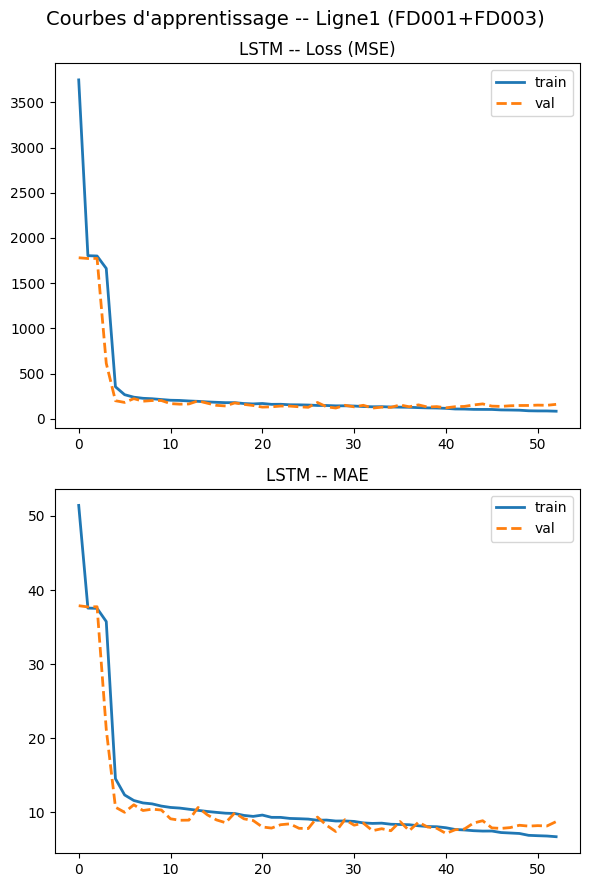

In [42]:
# Courbes d'apprentissage
import matplotlib.pyplot as plt

# Recuperation automatique de l'historique si la cellule d'entrainement
if 'histories' not in globals() or not histories:
    recovered = {}
    model_map = [
        ('LSTM', 'model_lstm'),
    ]
    for name, var_name in model_map:
        model_obj = globals().get(var_name)
        model_hist = getattr(model_obj, 'history', None) if model_obj is not None else None
        if model_hist is not None and hasattr(model_hist, 'history') and model_hist.history:
            recovered[name] = model_hist
    if recovered:
        histories = recovered
    else:
        raise NameError(
            "'histories' est introuvable. Execute les cellules dans cet ordre : "
            "1) Construction des sequences temporelles, "
            "2) Definition des modeles, "
            "3) Entrainement des modeles."
        )

fig, axes = plt.subplots(2, 1, figsize=(6, 9))
name = 'LSTM'
if name not in histories:
    raise KeyError(f"Historique manquant pour {name}. Reexecute la cellule 'Entrainement des modeles'.")
h = histories[name]

axes[0].plot(h.history['loss'],     label='train', lw=2)
axes[0].plot(h.history['val_loss'], label='val',   lw=2, linestyle='--')
axes[0].set_title(f'{name} -- Loss (MSE)')
axes[0].legend()

axes[1].plot(h.history['mae'],     label='train', lw=2)
axes[1].plot(h.history['val_mae'], label='val',   lw=2, linestyle='--')
axes[1].set_title(f'{name} -- MAE')
axes[1].legend()

plt.suptitle(f"Courbes d'apprentissage -- {LIGNE} ({label})", fontsize=14)
plt.tight_layout()
plt.show()

In [43]:
# Evaluation + Visualisation
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate(model, X, y):
    try:
        y_pred = model.predict(X, verbose=0).flatten()  # modeles Keras
    except TypeError:
        y_pred = model.predict(X).flatten()             # modeles sklearn
    return {
        'RMSE' : np.sqrt(mean_squared_error(y, y_pred)),
        'MAE'  : mean_absolute_error(y, y_pred),
        'R2'   : r2_score(y, y_pred),
        'preds': y_pred
    }

results = {}
print(f"{'─'*66}")
print(f"  {'Modele':<16} {'Split':<8} {'RMSE':>8} {'MAE':>8} {'R2':>8}")
print(f"{'─'*66}")

models_to_eval = [
    ('LSTM', model_lstm, X_train_m, X_test_m),
    ('Random Forest', model_rf, X_train_rf, X_test_rf),
]

for name, model, Xtr, Xte in models_to_eval:
    tr = evaluate(model, Xtr, y_train_m)
    te = evaluate(model, Xte, y_test_m)
    results[name] = te['preds']
    print(f"  {name:<16} {'train':<8} {tr['RMSE']:>8.2f} {tr['MAE']:>8.2f} {tr['R2']:>8.4f}")
    print(f"  {'':<16} {'TEST':<8} {te['RMSE']:>8.2f} {te['MAE']:>8.2f} {te['R2']:>8.4f}")

──────────────────────────────────────────────────────────────────
  Modele           Split        RMSE      MAE       R2
──────────────────────────────────────────────────────────────────
  LSTM             train       10.19     7.05   0.9410
                   TEST        20.17    12.34   0.7635
  Random Forest    train        9.09     5.80   0.9530
                   TEST        17.65    13.17   0.8190


Les résultats correspondent à la Ligne1 (FD001+FD003) — des moteurs évoluant dans une seule condition opérationnelle mais avec deux types de panne distincts, ce qui enrichit la diversité des scénarios de dégradation.
La MAE représente l'erreur moyenne de prédiction en cycles moteur :

LSTM : MAE test = 12.34 cycles — en moyenne le modèle se trompe d'environ 12 cycles sur l'estimation de la durée de vie restante.

Random Forest : MAE test = 13.17 cycles — légèrement moins précis que le LSTM sur cette métrique, contrairement aux résultats précédents où le RF dominait.

Le RMSE, plus sensible aux grosses erreurs ponctuelles, montre un écart notable :

LSTM : RMSE test = 20.17
Random Forest : RMSE test = 17.65

Le Random Forest présente un RMSE plus faible malgré une MAE légèrement supérieure — ce qui indique qu'il commet moins de grosses erreurs isolées que le LSTM. 

En maintenance industrielle, ce type d'erreur est critique : une forte sous-estimation de la RUL peut provoquer une intervention trop tardive, et une surestimation une immobilisation inutile de la machine.

Le R² confirme la hiérarchie sur la qualité globale d'ajustement :

LSTM : R² = 0.7635 — le modèle explique 76% de la variance de la RUL réelle
Random Forest : R² = 0.8190 — explique 82% de la variance, soit un ajustement nettement meilleur sur le jeu de test.

In [44]:
#  VERIFICATION COHERENCE DES DONNEES

RISK_THRESHOLD = 30   # << ajoute cette ligne

print("=== VERIFICATION COHERENCE DES DONNEES ===")
print(f"X_train_m  : {X_train_m.shape}   (sequences train)")
print(f"y_train_m  : {y_train_m.shape}   (cibles train)")
print(f"X_train_rf : {X_train_rf.shape}  (aplati pour RF)")
print(f"X_test_m   : {X_test_m.shape}    (1 seq par moteur)")
print(f"y_test_m   : {y_test_m.shape}    (1 RUL par moteur)")

assert X_train_m.shape[0] == y_train_m.shape[0], \
    f"ERREUR shape train : X={X_train_m.shape[0]} != y={y_train_m.shape[0]}"
assert X_test_m.shape[0] == y_test_m.shape[0], \
    f"ERREUR shape test : X_test={X_test_m.shape[0]} != y_test={y_test_m.shape[0]}"
assert X_train_rf.shape[0] == y_train_m.shape[0], \
    f"ERREUR shape RF train : X_rf={X_train_rf.shape[0]} != y={y_train_m.shape[0]}"

y_test_cls_check = (y_test_m <= RISK_THRESHOLD).astype(int)
n_risque = y_test_cls_check.sum()
n_total  = len(y_test_cls_check)
print(f"\nDistribution test apres merge ({LIGNE}) :")
print(f"  Normal   : {n_total - n_risque} moteurs ({(1 - n_risque/n_total)*100:.1f}%)")
print(f"  A risque : {n_risque} moteurs ({n_risque/n_total*100:.1f}%)")
print(f"  -> Desequilibre ratio 1:{int((n_total-n_risque)/max(n_risque,1))}")

if n_risque == 0:
    print("ATTENTION : aucun moteur 'a risque' dans le test !")
    print("Augmente RISK_THRESHOLD ou verifie le merge RUL.")
else:
    print("OK - Classes presentes dans le test.")

=== VERIFICATION COHERENCE DES DONNEES ===
X_train_m  : (35551, 50, 24)   (sequences train)
y_train_m  : (35551,)   (cibles train)
X_train_rf : (35551, 1200)  (aplati pour RF)
X_test_m   : (200, 50, 24)    (1 seq par moteur)
y_test_m   : (200,)    (1 RUL par moteur)

Distribution test apres merge (Ligne1) :
  Normal   : 155 moteurs (77.5%)
  A risque : 45 moteurs (22.5%)
  -> Desequilibre ratio 1:3
OK - Classes presentes dans le test.


In [45]:
# Evaluation croisee : Regression RUL + Classification risque pour LSTM et Random Forest
# Data Science :
# - Regression : predire la RUL restante en cycles
# - Classification : classer l'etat machine Normal / A risque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.metrics import roc_curve

RISK_THRESHOLD = 30

regression_rows = []

for model_name in ['LSTM', 'Random Forest']:
    y_pred = np.asarray(results[model_name]).ravel()
    n      = min(len(y_test_m), len(y_pred))  # securite
    yt     = y_test_m[:n]
    yp     = y_pred[:n]
    errors = np.abs(yt - yp)

    regression_rows.append({
        'Modele'              : model_name,
        'MAE (cycles)'        : round(mean_absolute_error(yt, yp), 2),
        'RMSE (cycles)'       : round(np.sqrt(mean_squared_error(yt, yp)), 2),
        'R2'                  : round(r2_score(yt, yp), 3),
        'Erreur max'          : round(errors.max(), 1),
        'Erreur mediane'      : round(np.median(errors), 1),
        '% pred <= 15 cycles' : round((errors <= 15).mean() * 100, 1),
        '% pred <= 30 cycles' : round((errors <= 30).mean() * 100, 1),
    })

regression_metrics = pd.DataFrame(regression_rows).set_index('Modele')

print("REGRESSION RUL")
display(regression_metrics)


REGRESSION RUL


,MAE (cycles),RMSE (cycles),R2,Erreur max,Erreur mediane,% pred <= 15 cycles,% pred <= 30 cycles
Modele,,,,,,,
LSTM,12.34,20.17,0.764,88.6,6.9,74.5,90.0
Random Forest,13.17,17.65,0.819,50.9,9.8,66.0,90.0


In [46]:
# CLASSIFICATION Normal / A risque

from sklearn.ensemble import RandomForestClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

y_train_cls = (y_train_m <= RISK_THRESHOLD).astype(int)
y_test_cls  = (y_test_m  <= RISK_THRESHOLD).astype(int)

print(f"Train — Normal: {(y_train_cls==0).sum():,}  |  A risque: {y_train_cls.sum():,} "
      f"({y_train_cls.mean()*100:.1f}%)")
print(f"Test  — Normal: {(y_test_cls==0).sum()}      |  A risque: {y_test_cls.sum()} "
      f"({y_test_cls.mean()*100:.1f}%)")

# --- Random Forest Classifier ---
model_rf_cls = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
model_rf_cls.fit(X_train_rf, y_train_cls)

rf_cls_proba = model_rf_cls.predict_proba(X_test_rf)[:, 1]
rf_cls_pred  = (rf_cls_proba >= 0.50).astype(int)
print("\nOK — Random Forest Classifier entraine")

# --- LSTM Classifier ---
# class_weight dans model.fit() pour compenser les 77.5% / 22.5%
n_pos  = y_train_cls.sum()
n_neg  = len(y_train_cls) - n_pos
cw_pos = n_neg / n_pos  # ~3.4 ici : la classe minoritaire pese 3x plus

model_lstm_cls = Sequential([
    LSTM(64, input_shape=(X_train_m.shape[1], X_train_m.shape[2]),
         return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])
model_lstm_cls.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_lstm_cls.fit(
    X_train_m, y_train_cls,
    validation_split=0.2,
    epochs=80,
    batch_size=128,
    callbacks=[EarlyStopping(monitor='val_loss', patience=10,
                              restore_best_weights=True, verbose=1)],
    class_weight={0: 1.0, 1: float(cw_pos)},
    verbose=1
)

lstm_cls_proba = model_lstm_cls.predict(X_test_m, verbose=0).ravel()
lstm_cls_pred  = (lstm_cls_proba >= 0.50).astype(int)
print("OK — LSTM Classifier entraine")

classification_outputs = {
    'LSTM'          : (lstm_cls_pred,  lstm_cls_proba),
    'Random Forest' : (rf_cls_pred,    rf_cls_proba),
}

Train — Normal: 29,351  |  A risque: 6,200 (17.4%)
Test  — Normal: 155      |  A risque: 45 (22.5%)

OK — Random Forest Classifier entraine
Epoch 1/80
223/223 ━━━━━━━━━━━━━━━━━━━━ 13s 47ms/step - accuracy: 0.9059 - loss: 0.3610 - val_accuracy: 0.9543 - val_loss: 0.1105
Epoch 2/80
223/223 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - accuracy: 0.9394 - loss: 0.2157 - val_accuracy: 0.9536 - val_loss: 0.1010
Epoch 3/80
223/223 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - accuracy: 0.9467 - loss: 0.1939 - val_accuracy: 0.9667 - val_loss: 0.0739
Epoch 4/80
223/223 ━━━━━━━━━━━━━━━━━━━━ 12s 53ms/step - accuracy: 0.9498 - loss: 0.1798 - val_accuracy: 0.9090 - val_loss: 0.2090
Epoch 5/80
223/223 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - accuracy: 0.9503 - loss: 0.1751 - val_accuracy: 0.9726 - val_loss: 0.0666
Epoch 6/80
223/223 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - accuracy: 0.9574 - loss: 0.1503 - val_accuracy: 0.9686 - val_loss: 0.0785
Epoch 7/80
223/223 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - accuracy: 0.9576 - loss:

In [47]:
# METRIQUES CLASSIFICATION

classification_rows = []

for model_name, (y_pred_cls, y_score_cls) in classification_outputs.items():
    tn, fp, fn, tp = confusion_matrix(y_test_cls, y_pred_cls).ravel()

    classification_rows.append({
        'Modele'         : model_name,
        'Accuracy'       : round(accuracy_score(y_test_cls, y_pred_cls), 3),
        'Precision'      : round(precision_score(y_test_cls, y_pred_cls,
                                                  zero_division=0), 3),
        'Recall'         : round(recall_score(y_test_cls, y_pred_cls,
                                               zero_division=0), 3),
        'F1'             : round(f1_score(y_test_cls, y_pred_cls,
                                          zero_division=0), 3),
        'AUC-ROC'        : round(roc_auc_score(y_test_cls, y_score_cls), 3),
        'Faux negatifs'  : int(fn),
        'Faux positifs'  : int(fp),
        'Vrais positifs' : int(tp),
    })

classification_metrics = pd.DataFrame(classification_rows).set_index('Modele')

print(f"CLASSIFICATION RISQUE (seuil RUL <= {RISK_THRESHOLD} cycles)")
display(classification_metrics)

CLASSIFICATION RISQUE (seuil RUL <= 30 cycles)


,Accuracy,Precision,Recall,F1,AUC-ROC,Faux negatifs,Faux positifs,Vrais positifs
Modele,,,,,,,,
LSTM,0.975,0.935,0.956,0.945,0.998,2,3,43
Random Forest,0.930,0.919,0.756,0.829,0.992,11,3,34


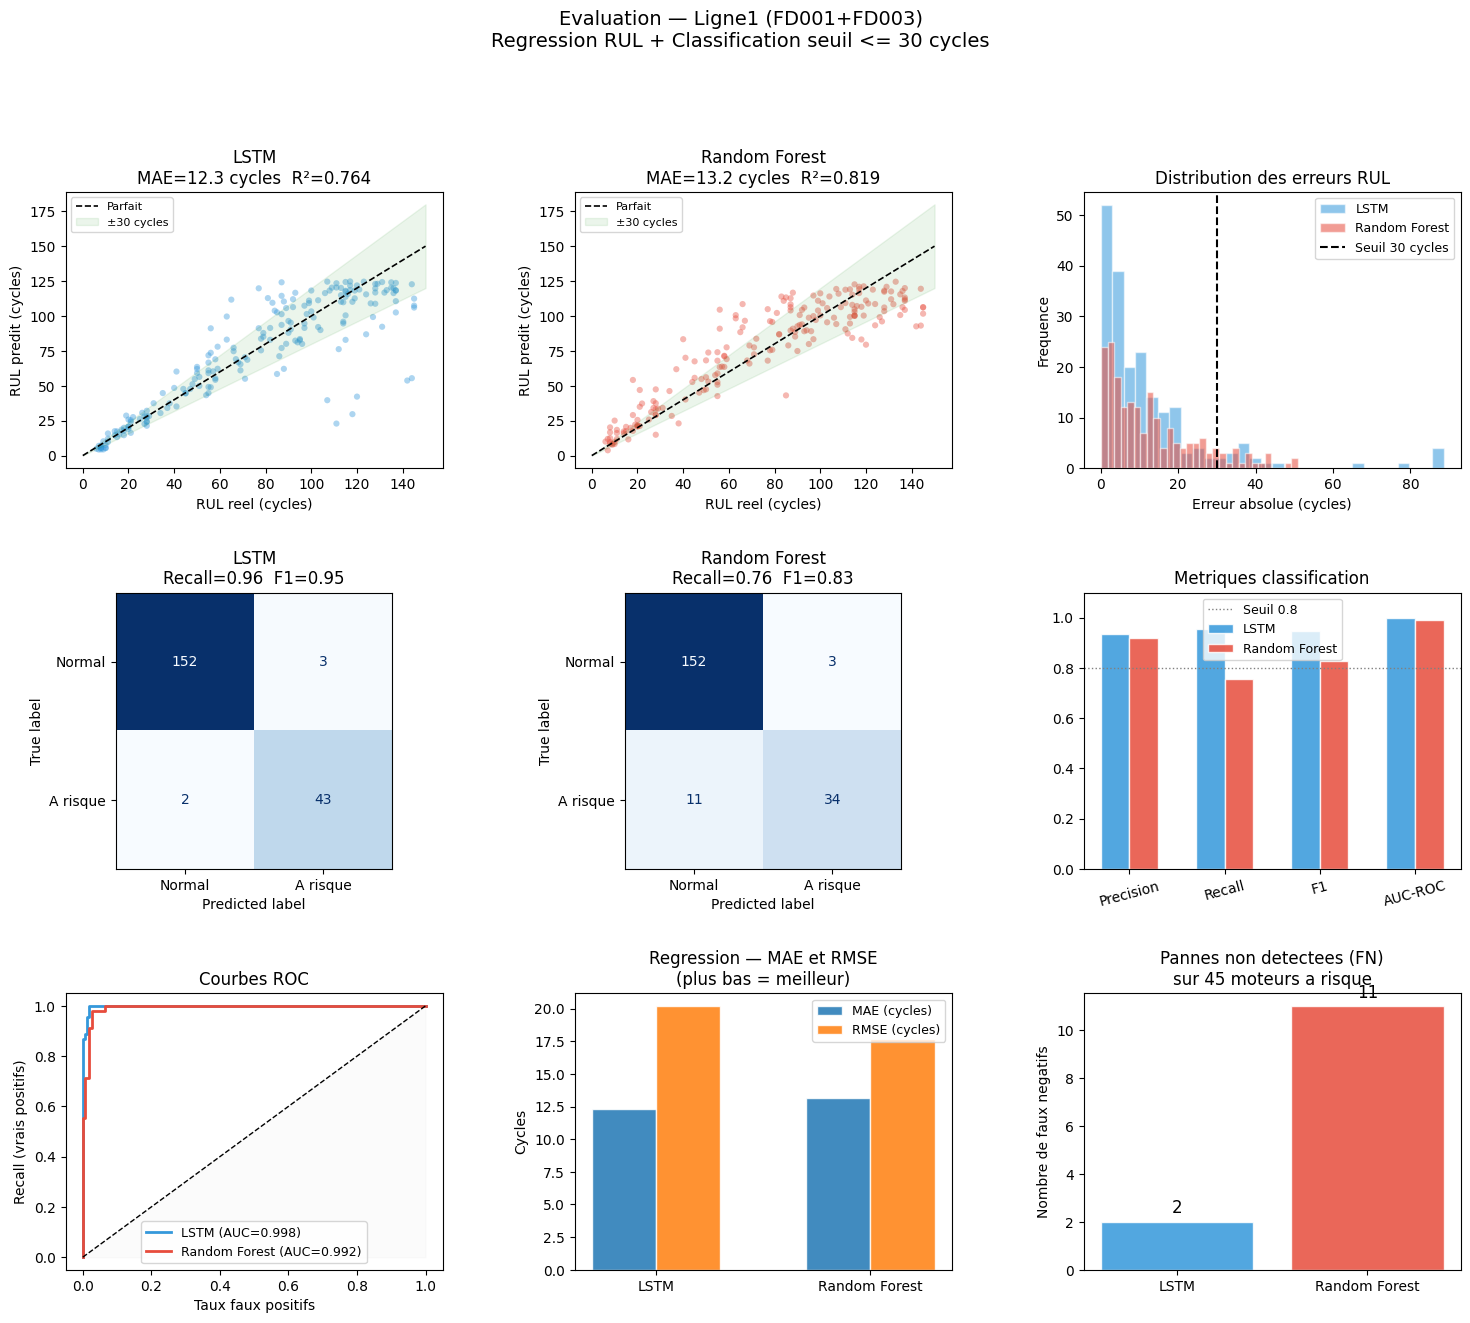

Figure sauvegardee : evaluation_Ligne1.png


In [48]:

# DASHBOARD VISUALISATION — 3x3

colors = {'LSTM': '#3498db', 'Random Forest': '#e74c3c'}

fig = plt.figure(figsize=(18, 14))
gs  = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.35)

# ── Ligne 1 : RUL réel vs prédit 
for col, model_name in enumerate(['LSTM', 'Random Forest']):
    ax   = fig.add_subplot(gs[0, col])
    yp   = np.asarray(results[model_name]).ravel()
    n    = min(len(y_test_m), len(yp))
    yt   = y_test_m[:n]
    mae  = mean_absolute_error(yt, yp[:n])
    r2   = r2_score(yt, yp[:n])
    lim  = max(yt.max(), yp[:n].max()) + 5

    ax.scatter(yt, yp[:n], alpha=0.4, s=20,
               color=colors[model_name], edgecolors='none')
    ax.plot([0, lim], [0, lim], 'k--', lw=1.2, label='Parfait')
    ax.fill_between([0, lim], [0, lim - 30], [0, lim + 30],
                    alpha=0.08, color='green', label='±30 cycles')
    ax.set_xlabel('RUL reel (cycles)')
    ax.set_ylabel('RUL predit (cycles)')
    ax.set_title(f'{model_name}\nMAE={mae:.1f} cycles  R²={r2:.3f}')
    ax.legend(fontsize=8)

# ── Ligne 1 col 3 : distribution des erreurs absolues
ax = fig.add_subplot(gs[0, 2])
for model_name in ['LSTM', 'Random Forest']:
    yp     = np.asarray(results[model_name]).ravel()
    n      = min(len(y_test_m), len(yp))
    errors = np.abs(y_test_m[:n] - yp[:n])
    ax.hist(errors, bins=30, alpha=0.55,
            color=colors[model_name], label=model_name, edgecolor='white')
ax.axvline(30, color='black', linestyle='--', lw=1.5, label='Seuil 30 cycles')
ax.set_xlabel('Erreur absolue (cycles)')
ax.set_ylabel('Frequence')
ax.set_title('Distribution des erreurs RUL')
ax.legend(fontsize=9)

# ── Ligne 2 : matrices de confusion 
for col, (model_name, (y_pred_cls, _)) in \
        enumerate(classification_outputs.items()):
    ax  = fig.add_subplot(gs[1, col])
    cm  = confusion_matrix(y_test_cls, y_pred_cls)
    ConfusionMatrixDisplay(cm, display_labels=['Normal', 'A risque'])\
        .plot(ax=ax, cmap='Blues', colorbar=False)
    rec = recall_score(y_test_cls, y_pred_cls, zero_division=0)
    f1  = f1_score(y_test_cls, y_pred_cls, zero_division=0)
    ax.set_title(f'{model_name}\nRecall={rec:.2f}  F1={f1:.2f}')

# ── Ligne 2 col 3 : barplot métriques classification 
ax      = fig.add_subplot(gs[1, 2])
metrics_to_plot = ['Precision', 'Recall', 'F1', 'AUC-ROC']
x       = np.arange(len(metrics_to_plot))
width   = 0.3
for i, (model_name, row) in \
        enumerate(classification_metrics[metrics_to_plot].iterrows()):
    ax.bar(x + i * width, row.values, width,
           label=model_name, color=colors[model_name],
           alpha=0.85, edgecolor='white')
ax.set_xticks(x + width / 2)
ax.set_xticklabels(metrics_to_plot, rotation=15)
ax.set_ylim(0, 1.1)
ax.axhline(0.8, color='gray', linestyle=':', lw=1, label='Seuil 0.8')
ax.set_title('Metriques classification')
ax.legend(fontsize=9)

# ── Ligne 3 : courbes ROC 
ax = fig.add_subplot(gs[2, 0])
for model_name, (_, y_score) in classification_outputs.items():
    fpr, tpr, _ = roc_curve(y_test_cls, y_score)
    auc = roc_auc_score(y_test_cls, y_score)
    ax.plot(fpr, tpr, lw=2,
            color=colors[model_name],
            label=f'{model_name} (AUC={auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.fill_between([0, 1], [0, 1], alpha=0.03, color='gray')
ax.set_xlabel('Taux faux positifs')
ax.set_ylabel('Recall (vrais positifs)')
ax.set_title('Courbes ROC')
ax.legend(fontsize=9)

# ── Ligne 3 col 2 : MAE / RMSE régression 
ax    = fig.add_subplot(gs[2, 1])
x     = np.arange(len(regression_metrics))
width = 0.3
for i, col_name in enumerate(['MAE (cycles)', 'RMSE (cycles)']):
    ax.bar(x + i * width,
           regression_metrics[col_name].values,
           width, label=col_name, alpha=0.85, edgecolor='white')
ax.set_xticks(x + width / 2)
ax.set_xticklabels(regression_metrics.index)
ax.set_ylabel('Cycles')
ax.set_title('Regression — MAE et RMSE\n(plus bas = meilleur)')
ax.legend(fontsize=9)

# ── Ligne 3 col 3 : faux négatifs 
ax      = fig.add_subplot(gs[2, 2])
fn_vals = classification_metrics['Faux negatifs'].values
bars    = ax.bar(
    classification_metrics.index, fn_vals,
    color=[colors[m] for m in classification_metrics.index],
    alpha=0.85, edgecolor='white'
)
for bar, v in zip(bars, fn_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.2,
            str(v), ha='center', va='bottom', fontsize=12)
ax.set_ylabel('Nombre de faux negatifs')
ax.set_title(f'Pannes non detectees (FN)\n'
             f'sur {y_test_cls.sum()} moteurs a risque')

plt.suptitle(
    f'Evaluation — {LIGNE} ({label})\n'
    f'Regression RUL + Classification seuil <= {RISK_THRESHOLD} cycles',
    fontsize=14, y=1.01
)
plt.savefig(f'evaluation_{LIGNE}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure sauvegardee : evaluation_{LIGNE}.png")

In [49]:
print(regression_metrics.columns.tolist())

['MAE (cycles)', 'RMSE (cycles)', 'R2', 'Erreur max', 'Erreur mediane', '% pred <= 15 cycles', '% pred <= 30 cycles']


In [50]:
from IPython.display import display, HTML

RISK_THRESHOLD = 30

best_reg = regression_metrics['MAE (cycles)'].idxmin()
best_cls = classification_metrics\
    .sort_values(['Recall', 'F1', 'AUC-ROC'], ascending=False)\
    .index[0]

mae_best = regression_metrics.loc[best_reg, 'MAE (cycles)']
pct_30   = regression_metrics.loc[best_reg, '% pred <= 30 cycles']
rec_best = classification_metrics.loc[best_cls, 'Recall']
f1_best  = classification_metrics.loc[best_cls, 'F1']
fn_lstm  = int(classification_metrics.loc['LSTM', 'Faux negatifs'])
fn_rf    = int(classification_metrics.loc['Random Forest', 'Faux negatifs'])
n_risque = int(y_test_cls.sum())

# ── helper : construit une table HTML propre depuis un DataFrame 

def df_to_html(df, caption, fmt_dict, green_min=None, green_max=None):
    green_min = green_min or []
    green_max = green_max or []
    min_vals  = {c: df[c].min() for c in green_min}
    max_vals  = {c: df[c].max() for c in green_max}

    rows_html = ""
    for i, (idx, row) in enumerate(df.iterrows()):
        bg    = "#3b2a1a" if i % 2 == 0 else "#2a1f14"  # marron foncé / marron très foncé
        cells = (f'<td style="padding:7px 14px;background:{bg};'
                 f'font-weight:bold;color:white;">{idx}</td>')

        for col in df.columns:
            val     = row[col]
            fmt     = fmt_dict.get(col, '{}')
            txt     = fmt.format(val)
            cell_bg = bg

            if col in green_min and val == min_vals[col]:
                cell_bg = "#6b8f3e"   # vert olive
            if col in green_max and val == max_vals[col]:
                cell_bg = "#6b8f3e"   # vert olive

            cells += (f'<td style="text-align:center;padding:7px 14px;'
                      f'background:{cell_bg};color:white;">{txt}</td>')

        rows_html += f"<tr>{cells}</tr>"

    headers = "".join(
        f'<th style="background:#1a1a1a;color:white;padding:8px 14px;'
        f'text-align:center;">{c}</th>'
        for c in [""] + list(df.columns)
    )

    return f"""
    <div style="margin-bottom:24px;">
      <div style="font-size:14px;font-weight:bold;margin-bottom:6px;
                  color:white;">{caption}</div>
      <table style="border-collapse:collapse;font-family:sans-serif;width:auto;">
        <thead><tr>{headers}</tr></thead>
        <tbody>{rows_html}</tbody>
      </table>
    </div>
    """

# ── Tableau regression ────────────────────────────────────────────────────
reg_fmt = {
    'MAE (cycles)'        : '{:.2f}',
    'RMSE (cycles)'       : '{:.2f}',
    'R2'                  : '{:.3f}',
    'Erreur max'          : '{:.1f}',
    'Erreur mediane'      : '{:.1f}',
    '% pred <= 15 cycles' : '{:.1f}%',
    '% pred <= 30 cycles' : '{:.1f}%',
}
reg_table = df_to_html(
    regression_metrics,
    caption   = "Regression RUL",
    fmt_dict  = reg_fmt,
    green_min = ['MAE (cycles)', 'RMSE (cycles)'],
    green_max = ['R2', '% pred <= 30 cycles'],
)

# ── Tableau classification ────────────────────────────────────────────────
cls_fmt = {
    'Accuracy'       : '{:.3f}',
    'Precision'      : '{:.3f}',
    'Recall'         : '{:.3f}',
    'F1'             : '{:.3f}',
    'AUC-ROC'        : '{:.3f}',
    'Faux negatifs'  : '{:.0f}',  
    'Faux positifs'  : '{:.0f}',
    'Vrais positifs' : '{:.0f}',
}
cls_table = df_to_html(
    classification_metrics,
    caption   = f"Classification risque (seuil RUL <= {RISK_THRESHOLD} cycles)",
    fmt_dict  = cls_fmt,
    green_max = ['Recall', 'F1', 'AUC-ROC'],
    green_min = ['Faux negatifs'],
)

# ── Tableau recommandation ────────────────────────────────────────────────
reco_table = f"""
<div style="margin-bottom:24px;">
  <div style="font-size:14px;font-weight:bold;margin-bottom:6px;">
    Recommandation — double seuil d'alerte
  </div>
  <table style="border-collapse:collapse;font-family:sans-serif;">
    <thead>
      <tr>
        <th style="background:#343a40;color:white;padding:8px 16px;">Seuil</th>
        <th style="background:#343a40;color:white;padding:8px 16px;">RUL</th>
        <th style="background:#343a40;color:white;padding:8px 16px;">Action</th>
      </tr>
    </thead>
    <tbody>
      <tr style="background:#fff8f0;">
        <td style="padding:7px 16px;color:#fd7e14;font-weight:bold;">Alerte</td>
        <td style="padding:7px 16px;text-align:center;">≤ 50 cycles</td>
        <td style="padding:7px 16px;">Notifier equipe maintenance</td>
      </tr>
      <tr style="background:#fff0f0;">
        <td style="padding:7px 16px;color:#dc3545;font-weight:bold;">Critique</td>
        <td style="padding:7px 16px;text-align:center;">≤ {RISK_THRESHOLD} cycles</td>
        <td style="padding:7px 16px;">Intervention immediate</td>
      </tr>
    </tbody>
  </table>
</div>
"""

# ── Synthese ──────────────────────────────────────────────────────────────
synthese = f"""
<div style="font-family:sans-serif;margin:20px 0;">
  <h3 style="border-bottom:2px solid #343a40;padding-bottom:6px;">
    Conclusion metier — {LIGNE} ({label})
  </h3>
  <p>
    <b>Meilleur modele regression (MAE) :</b> {best_reg}
    &nbsp;|&nbsp; MAE = <b>{mae_best:.1f} cycles</b>
    &nbsp;|&nbsp; {pct_30:.0f}% des predictions a ±30 cycles
  </p>
  <p>
    <b>Meilleur modele classification (Recall + F1) :</b> {best_cls}
    &nbsp;|&nbsp; Recall = <b>{rec_best:.2f}</b>
    &nbsp;|&nbsp; F1 = <b>{f1_best:.2f}</b>
  </p>
  <p>
    Faux negatifs — LSTM : <b>{fn_lstm}</b>
    &nbsp;|&nbsp; Random Forest : <b>{fn_rf}</b>
    &nbsp;|&nbsp; sur <b>{n_risque}</b> moteurs a risque dans le test<br>
    <span style="color:#dc3545;">
      Chaque faux negatif = panne non anticipee = arret non planifie.
    </span>
  </p>
</div>
"""

# ── Affichage ─────────────────────────────────────────────────────────────
display(HTML(synthese + reg_table + cls_table + reco_table))

Classification Normal / À risque

C'est ici que l'écart entre les deux modèles est le plus significatif,

Le LSTM atteint un Recall de 0.956, ce qui signifie qu'il détecte 43 moteurs à risque sur 45 — il en rate seulement 2. Le Random Forest n'en détecte que 34, en ratant 11, soit 5.5 fois plus de pannes non anticipées. 

Le F1 de 0.945 pour le LSTM confirme que ce Recall élevé ne se fait pas au prix d'une explosion des fausses alarmes : les deux modèles ont exactement le même nombre de faux positifs (3), donc le LSTM est à la fois plus sensible aux vrais risques et aussi précis sur les fausses alertes. C'est le meilleur des deux mondes en contexte industriel.

L'AUC-ROC de 0.998 pour le LSTM est remarquable — proche de 1, il indique que le modèle discrimine quasi-parfaitement les moteurs normaux des moteurs à risque sur l'ensemble du spectre de seuils de décision. Le Random Forest obtient 0.992, également très bon mais légèrement en retrait.

Le LSTM est le modèle recommandé pour MECHA sur la Ligne1, principalement grâce à son Recall de 0.956 et ses seulement 2 faux négatifs sur 45 moteurs à risque. Son seul point de vigilance reste son erreur max de 88.6 cycles en régression RUL sur certains moteurs — ces cas atypiques mériteraient une investigation pour identifier s'ils correspondent à des profils de dégradation non représentés dans FD001 ou FD003.